# 04 — Global Equity Markets

**Chain position:** Macro → Risk → Rates → `Global Equity` → India → Companies

Fourteen indices across the US, Europe, Asia, LatAm and India. The purpose is not to
admire returns — it is to answer three questions that determine how much of an Indian
position is really an India bet:

1. **Who is leading, and by how much?**
2. **Are these markets moving together?** If global correlation is high, a "diversified"
   book of country exposures is one position wearing several hats.
3. **Where does India sit against the world?** That relative-strength line is the bridge
   into notebook 05.

Every market here trades on its own calendar and closes at a different hour. Fourteen
national holiday schedules will not line up, so the frame is aligned deliberately and
the per-index as-of stamps are printed before any comparison is drawn.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard,
                 indicators as ind, fundamentals as fnd, score, viz)

# Set REFRESH = True to force a live re-fetch of every source, ignoring the cache.
REFRESH = False
mkt.bootstrap(refresh=REFRESH)

mkt v1.0.0 | run 2026-09-09 10:46 | REFRESH=False | cache=G:\stock market analysis\data\cache


## 1. Assemble the universe

One ticker at a time, then aligned onto a common business-day calendar. Any index that
fails to resolve is reported and dropped — never silently skipped.

In [2]:
eq_frames, eq_failed = fetch.price_histories(
    list(config.GLOBAL_EQUITY), period=config.LONG_HISTORY_PERIOD)
if eq_failed:
    print("Dropped (reported, not hidden):")
    for t, why in eq_failed:
        print(f"  - {t} ({config.GLOBAL_EQUITY[t][0]}): {why}")
else:
    print(f"All {len(eq_frames)} indices resolved.")

px = align.align_multi(eq_frames, calendar="B", max_gap=3)
names = {t: config.GLOBAL_EQUITY[t][0] for t in px.columns}
regions = {config.GLOBAL_EQUITY[t][0]: config.GLOBAL_EQUITY[t][1] for t in px.columns}
px.columns = [names[c] for c in px.columns]

rate = align.assert_alignment(px, max_nan_pct=8.0, label="global equity")
print(f"\nPost-alignment NaN rate: {rate}%  (trap #1 guard passed)")
print("Residual NaNs are genuine holiday divergence across 14 national calendars.")

  fetched 14/14 tickers in 9s
All 14 indices resolved.



Post-alignment NaN rate: 0.25%  (trap #1 guard passed)
Residual NaNs are genuine holiday divergence across 14 national calendars.


In [3]:
print("Per-index as-of stamps. These are NOT all the same day -- Asia and Europe have")
print("settled while the US session may not have. Nothing below compares across rows")
print("without this being visible first.\n")
display(align.describe_asof(px))

Per-index as-of stamps. These are NOT all the same day -- Asia and Europe have
settled while the US session may not have. Nothing below compares across rows
without this being visible first.



,series,as_of,value,lag_days
0,S&P 500,2026-09-08,"7,673.52",1
1,Nasdaq 100,2026-09-08,"29,507.70",1
2,Russell 2000,2026-09-08,"2,960.20",1
3,DAX,2026-09-08,"26,007.63",1
4,FTSE 100,2026-09-08,"10,811.70",1
5,Euro Stoxx 50,2026-09-08,"6,413.17",1
6,Nikkei 225,2026-09-09,"65,196.21",0
7,Hang Seng,2026-09-09,"25,309.48",0
8,Shanghai Composite,2026-09-09,"3,949.60",0
9,KOSPI,2026-09-09,"7,066.61",0


## 2. Performance

Rebased to 100 so shape is comparable, then a trailing-return table. India is
highlighted throughout.

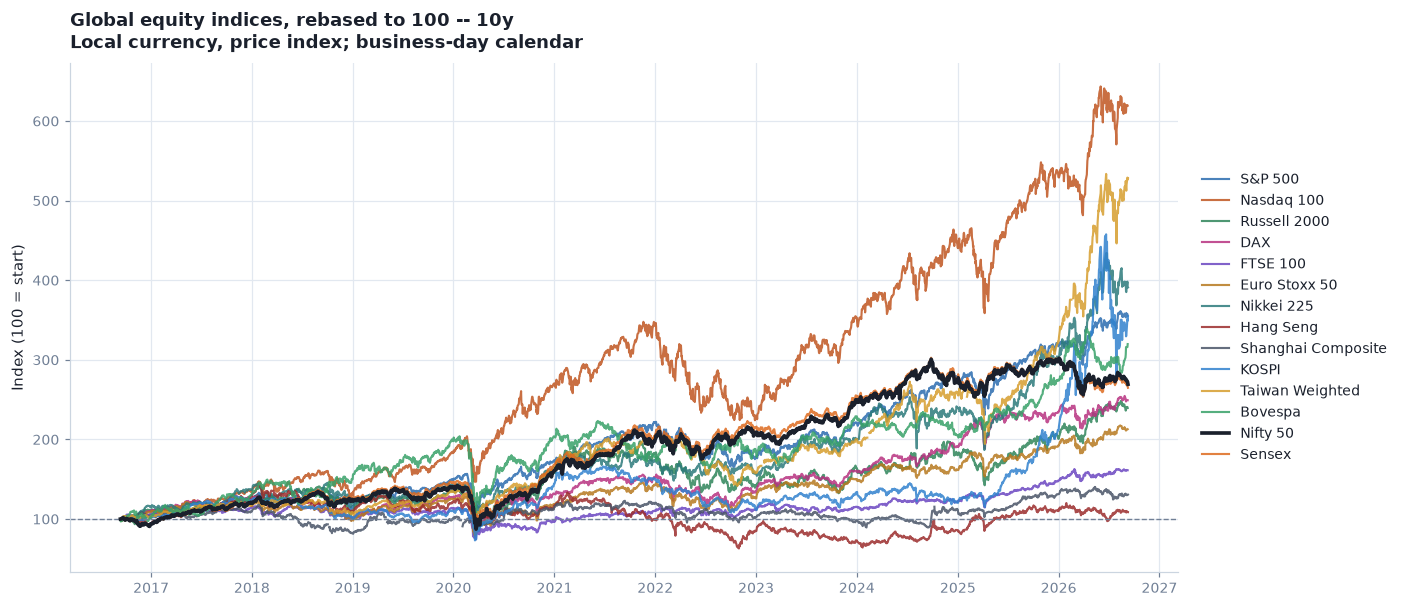

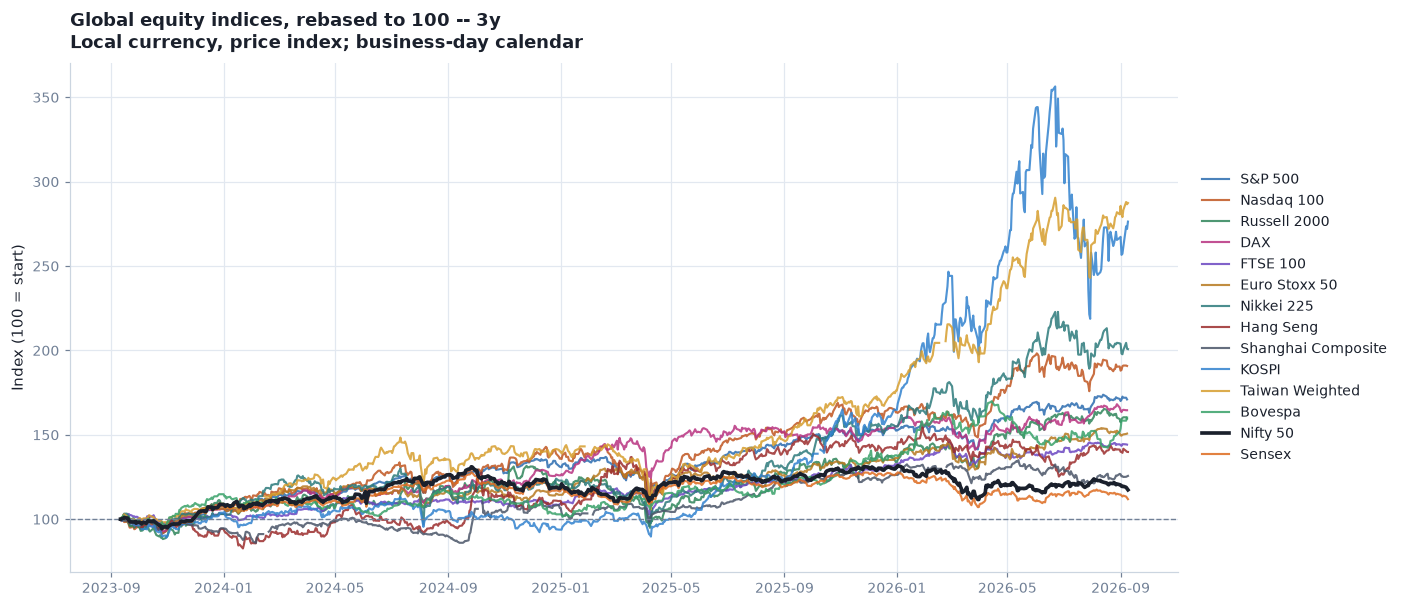

In [4]:
for years, tag in [(10, "10y"), (3, "3y")]:
    win = px.loc[px.index >= px.index.max() - pd.Timedelta(days=365 * years)]
    reb = align.rebase(win.dropna(how="all"), 100)
    fig, ax = plt.subplots(figsize=(13, 6))
    viz.line(reb, ax=ax, title_=f"Global equity indices, rebased to 100 -- {tag}",
             sub="Local currency, price index; business-day calendar",
             ylabel="Index (100 = start)", highlight="Nifty 50", legend_out=True)
    ax.axhline(100, color=viz.MUTED, ls="--", lw=0.9)
    viz.save(fig, f"04_rebased_{tag}"); plt.show()

In [5]:
rows = []
for c in px.columns:
    s = px[c].dropna()
    if s.empty:
        continue
    r = ind.return_table(s)
    r["region"] = regions[c]
    r["level"] = s.iloc[-1]
    r["as_of"] = s.index[-1].date()
    rows.append(pd.Series(r, name=c))

perf = pd.DataFrame(rows)
cols = ["region", "level", "as_of", "YTD_%", "1Y_%", "3Y_%", "5Y_%",
        "CAGR_%", "MaxDD_%", "Vol_%"]
display(perf[cols].sort_values("1Y_%", ascending=False).round(2))

,region,level,as_of,YTD_%,1Y_%,3Y_%,5Y_%,CAGR_%,MaxDD_%,Vol_%
KOSPI,Asia,"7,066.61",2026-09-09,67.69,116.76,177.37,126.08,8.70,-54.54,73.33
Taiwan Weighted,Asia,"47,228.15",2026-09-09,63.06,90.01,184.92,170.27,10.27,-58.31,32.73
Nikkei 225,Asia,"65,196.21",2026-09-09,29.51,50.02,99.95,114.59,7.35,-61.37,31.71
Bovespa,LatAm,"187,367.00",2026-09-08,16.29,32.14,62.49,62.42,8.51,-59.96,16.47
Nasdaq 100,US,"29,507.70",2026-09-08,16.86,24.18,93.11,89.63,15.75,-53.71,21.93
Russell 2000,US,"2,960.20",2026-09-08,19.27,23.60,59.88,31.62,7.42,-59.89,13.41
Euro Stoxx 50,Europe,"6,413.17",2026-09-08,10.64,19.59,51.35,53.53,2.22,-60.29,12.22
S&P 500,US,"7,673.52",2026-09-08,12.10,18.14,72.15,70.78,9.29,-56.78,11.60
FTSE 100,Europe,"10,811.70",2026-09-08,8.86,17.25,44.58,53.92,3.09,-47.83,8.80
DAX,Europe,"26,007.63",2026-09-08,6.20,9.24,65.23,66.47,7.80,-54.77,12.73


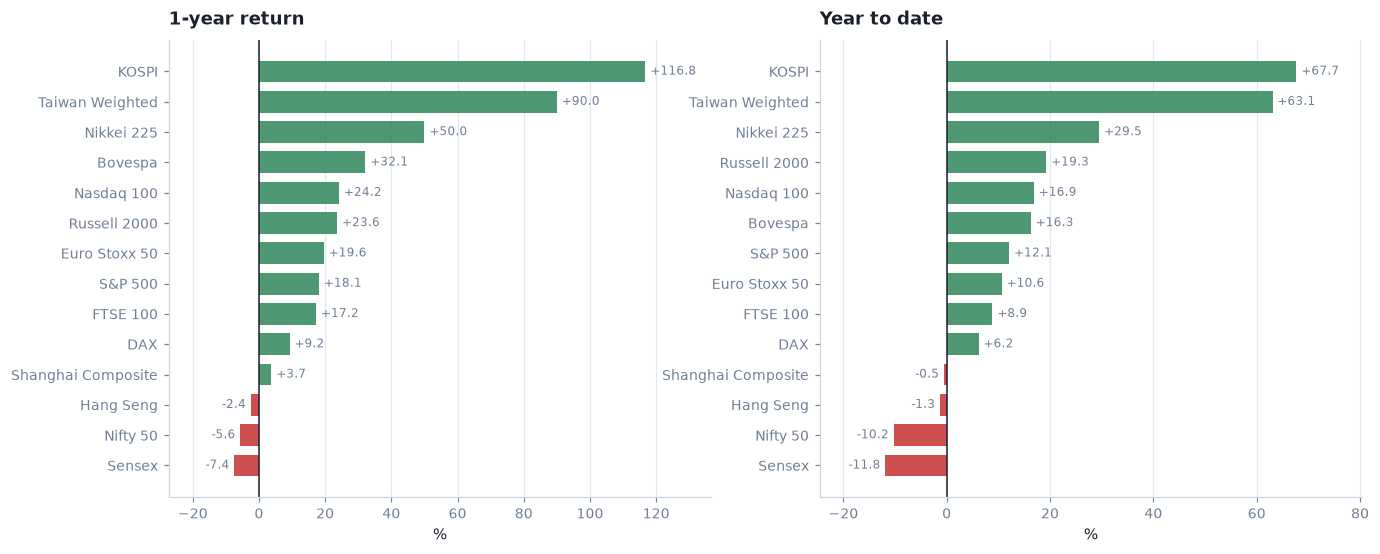

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.4))
viz.ranked_bar(perf["1Y_%"].dropna(), ax=a1, title_="1-year return", xlabel="%")
viz.ranked_bar(perf["YTD_%"].dropna(), ax=a2, title_="Year to date", xlabel="%")
viz.save(fig, "04_returns_ranked"); plt.show()

## 3. Drawdown from all-time high

Return tells you what happened; drawdown tells you where you are standing. An index up
15% on the year while 25% below its high is in a very different place from one up 15%
at a record.

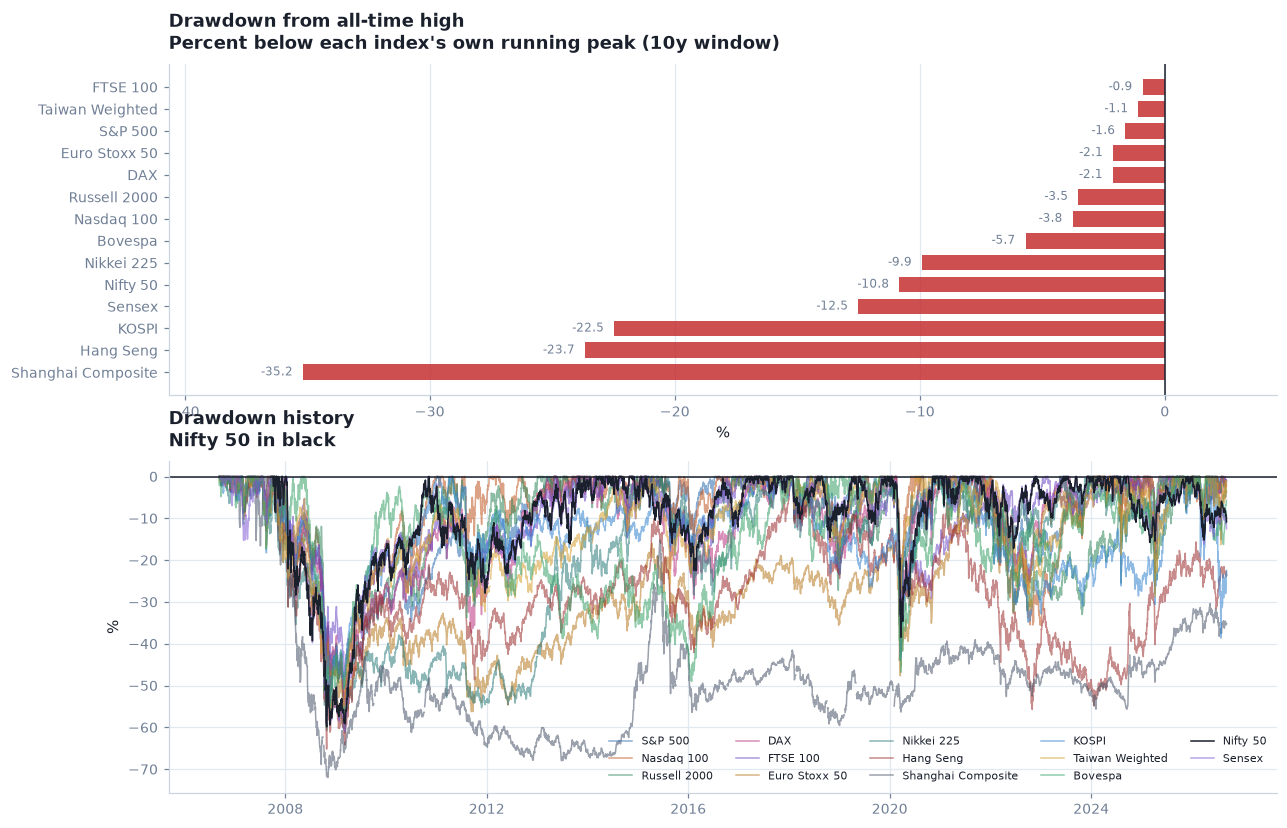

In [7]:
dd = pd.DataFrame({c: ind.drawdown(px[c].dropna()) for c in px.columns})
dd_now = dd.ffill().iloc[-1].dropna().sort_values()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 8.6),
                             gridspec_kw={"height_ratios": [1, 1]})
viz.ranked_bar(dd_now, ax=a1, title_="Drawdown from all-time high",
               sub="Percent below each index's own running peak (10y window)", xlabel="%")
for c in dd.columns:
    a2.plot(dd.index, dd[c], lw=1.0,
            color=viz.INK if c == "Nifty 50" else None,
            alpha=1.0 if c == "Nifty 50" else 0.55,
            zorder=3 if c == "Nifty 50" else 2, label=c)
a2.axhline(0, color=viz.INK, lw=1)
viz.title(a2, "Drawdown history", "Nifty 50 in black")
a2.legend(ncol=5, fontsize=7.5); a2.set_ylabel("%")
viz.save(fig, "04_drawdowns"); plt.show()

## 4. Correlation and dispersion

Correlations on daily returns, computed after alignment. Dispersion — the cross-sectional
spread of returns — is the other half: high correlation with high dispersion means
markets move together but by very different amounts, which is where country selection
actually pays.

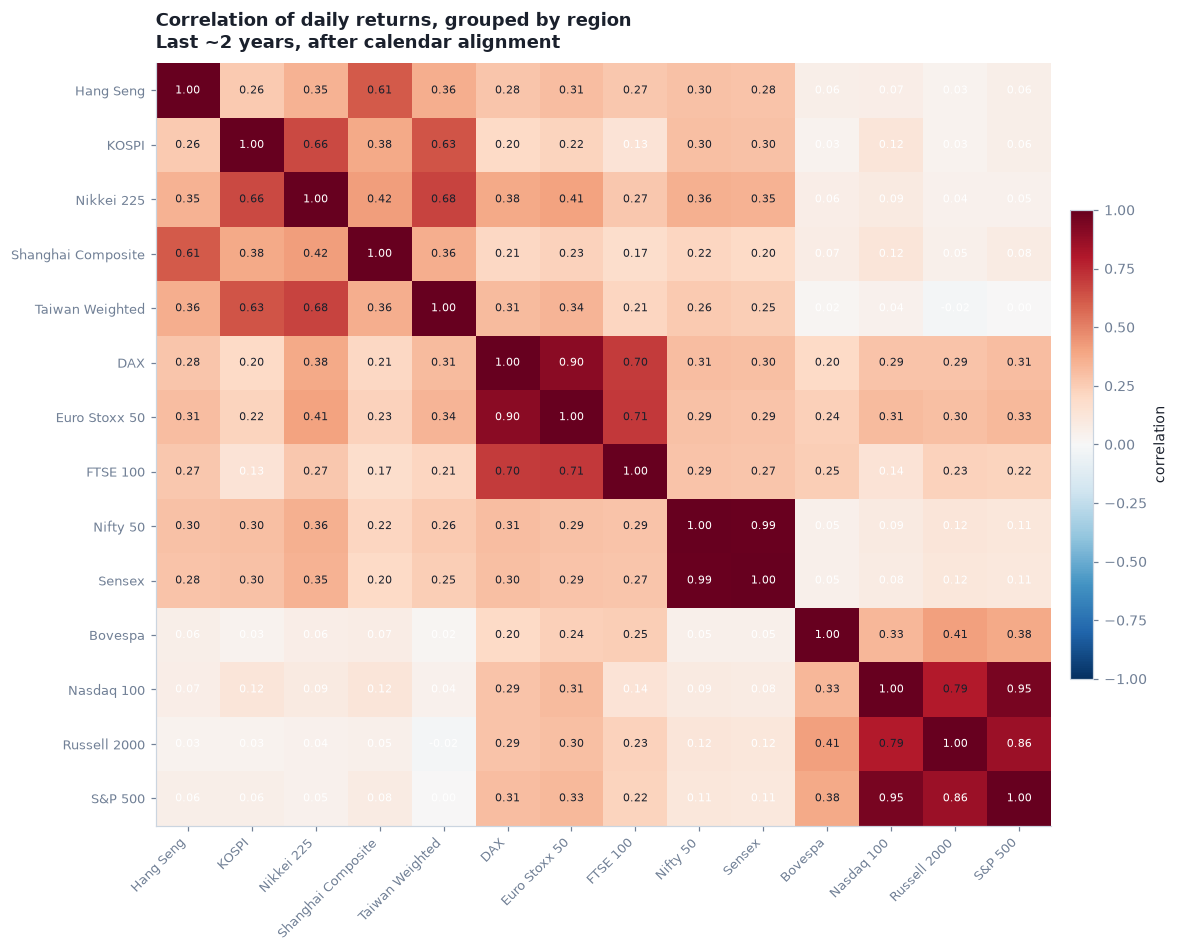

Nifty 50 correlation with each market:


,corr
Bovespa,0.05
Nasdaq 100,0.09
S&P 500,0.11
Russell 2000,0.12
Shanghai Composite,0.22
Taiwan Weighted,0.26
FTSE 100,0.29
Euro Stoxx 50,0.29
Hang Seng,0.30
KOSPI,0.30



Mean correlation of Nifty 50 with the rest of the world: +0.28
Mean pairwise correlation across all markets: +0.28


In [8]:
rets = align.to_returns(px).dropna(how="all")
corr = rets.tail(504).corr()

order = sorted(corr.columns, key=lambda c: (regions[c], c))
corr = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(11, 9))
viz.heatmap(corr, ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, fmt="{:.2f}",
            title_="Correlation of daily returns, grouped by region",
            sub="Last ~2 years, after calendar alignment",
            cbar_label="correlation")
viz.save(fig, "04_correlation"); plt.show()

india_corr = corr["Nifty 50"].drop("Nifty 50").sort_values()
print("Nifty 50 correlation with each market:")
display(india_corr.to_frame("corr").round(2))
print(f"\nMean correlation of Nifty 50 with the rest of the world: "
      f"{india_corr.mean():+.2f}")
print(f"Mean pairwise correlation across all markets: "
      f"{corr.where(~np.eye(len(corr), dtype=bool)).stack().mean():+.2f}")

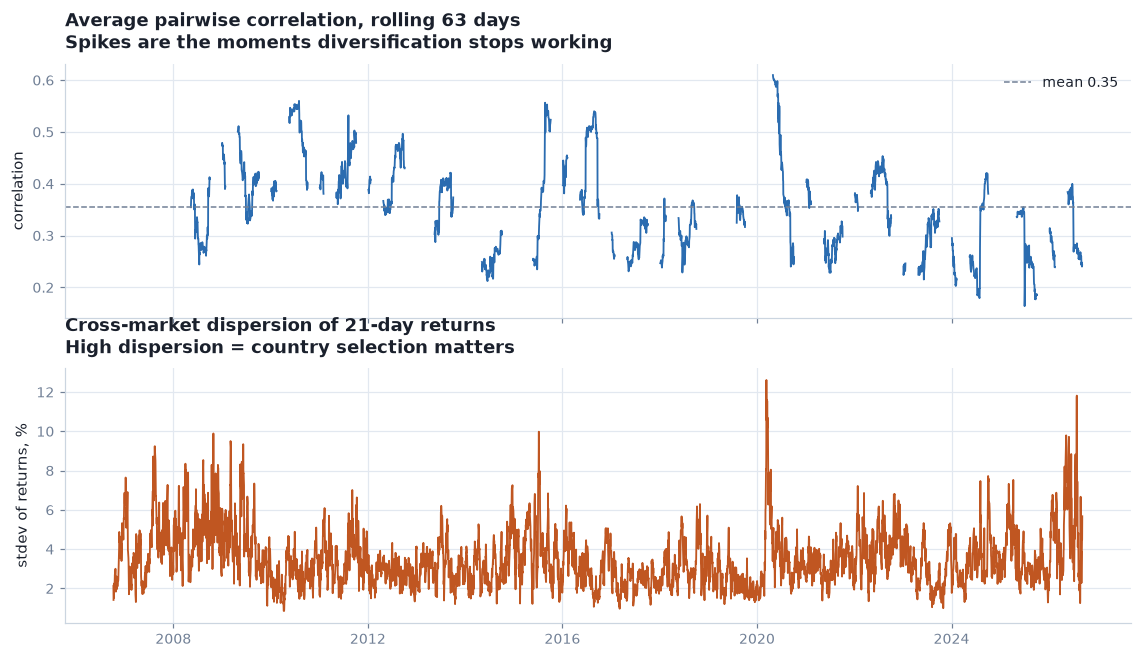

Rolling correlation now +0.24 (mean +0.35); dispersion now 5.68% (mean 3.47%)


In [9]:
roll_disp = rets.rolling(21).sum().std(axis=1) * 100
roll_corr = rets.rolling(63).corr().groupby(level=0).apply(
    lambda m: m.values[np.triu_indices_from(m.values, k=1)].mean())

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12.5, 6.6), sharex=True)
a1.plot(roll_corr.index, roll_corr.values, color=viz.PALETTE[0], lw=1.2)
a1.axhline(float(roll_corr.mean()), color=viz.MUTED, ls="--", lw=1,
           label=f"mean {roll_corr.mean():.2f}")
viz.title(a1, "Average pairwise correlation, rolling 63 days",
          "Spikes are the moments diversification stops working")
a1.legend(); a1.set_ylabel("correlation")
a2.plot(roll_disp.index, roll_disp.values, color=viz.PALETTE[1], lw=1.2)
viz.title(a2, "Cross-market dispersion of 21-day returns",
          "High dispersion = country selection matters")
a2.set_ylabel("stdev of returns, %")
viz.save(fig, "04_corr_dispersion"); plt.show()

print(f"Rolling correlation now {float(roll_corr.dropna().iloc[-1]):+.2f} "
      f"(mean {roll_corr.mean():+.2f}); dispersion now "
      f"{float(roll_disp.dropna().iloc[-1]):.2f}% (mean {roll_disp.mean():.2f}%)")

## 5. Relative strength matrix

Each cell is the row index's excess return over the column index across the window. The
Nifty 50 row is the one to read: it is India's scorecard against every other market at
once.

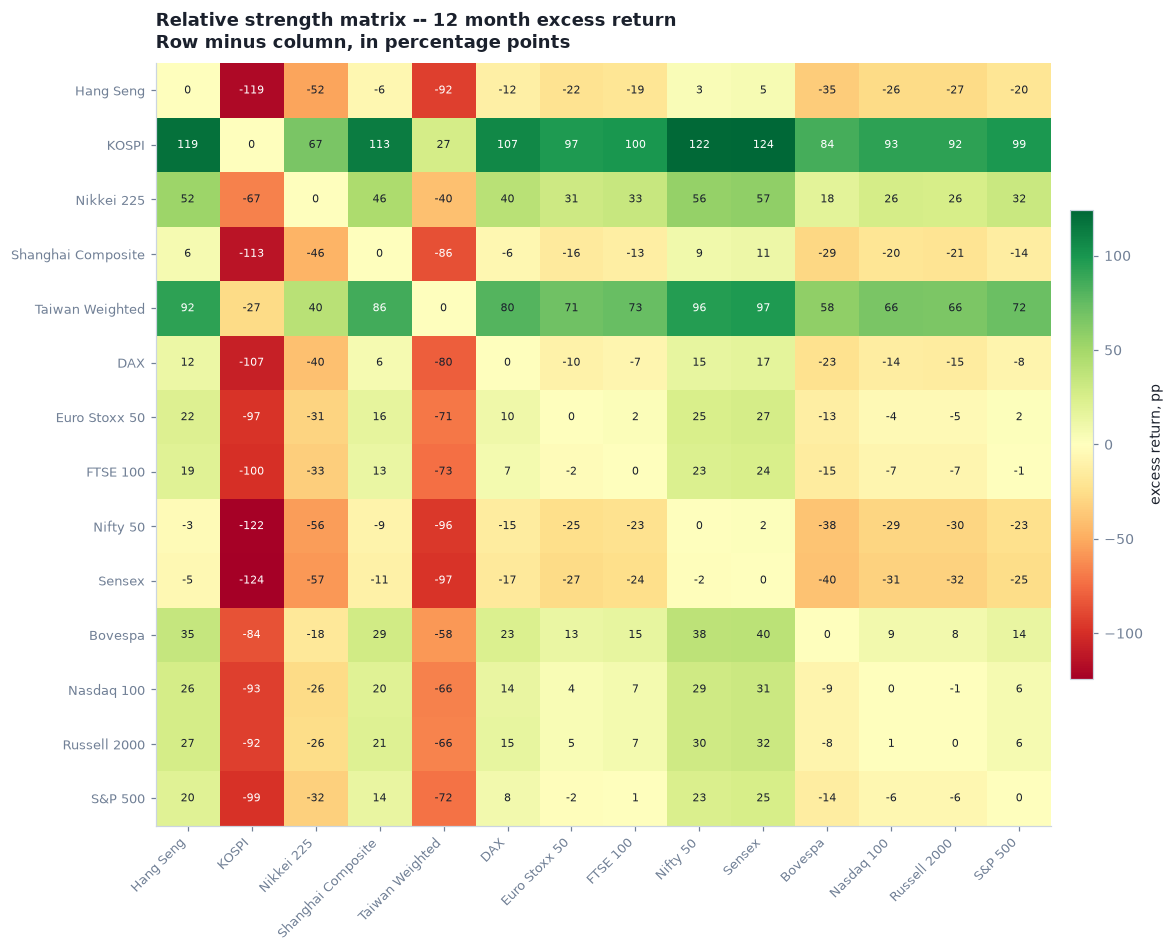

Average excess return against all other markets (12m):


,"avg excess, pp"
KOSPI,89.00
Taiwan Weighted,62.20
Nikkei 225,22.20
Bovespa,4.50
Russell 2000,-3.50
Nasdaq 100,-4.00
Euro Stoxx 50,-8.40
S&P 500,-10.00
FTSE 100,-10.80
DAX,-18.20


In [10]:
def rs_matrix(frame, days):
    end = frame.index.max()
    start = end - pd.Timedelta(days=days)
    sub = frame.loc[start:].dropna(axis=1, how="all")
    ret = {}
    for c in sub.columns:
        s = sub[c].dropna()
        ret[c] = (s.iloc[-1] / s.iloc[0] - 1) * 100 if len(s) > 1 else np.nan
    r = pd.Series(ret)
    return pd.DataFrame({a: {b: r[a] - r[b] for b in r.index} for a in r.index}).T

rs12 = rs_matrix(px, 365).loc[order, order]
fig, ax = plt.subplots(figsize=(11, 9))
viz.heatmap(rs12, ax=ax, cmap="RdYlGn", fmt="{:.0f}",
            title_="Relative strength matrix -- 12 month excess return",
            sub="Row minus column, in percentage points",
            cbar_label="excess return, pp")
viz.save(fig, "04_rs_matrix"); plt.show()

rs_rank = rs12.mean(axis=1).sort_values(ascending=False)
print("Average excess return against all other markets (12m):")
display(rs_rank.to_frame("avg excess, pp").round(1))

## 6. India versus the world — the bridge

Two ratio lines: the Nifty against the S&P 500, and the Nifty against an equal-weighted
basket of every other market in the universe. Both are rebased so only the *shape*
matters.

Rising = India is being rewarded relative to the alternative. Falling = capital is
finding better risk-adjusted returns elsewhere, which is the more important case: it
means an India-specific reason is needed to stay.

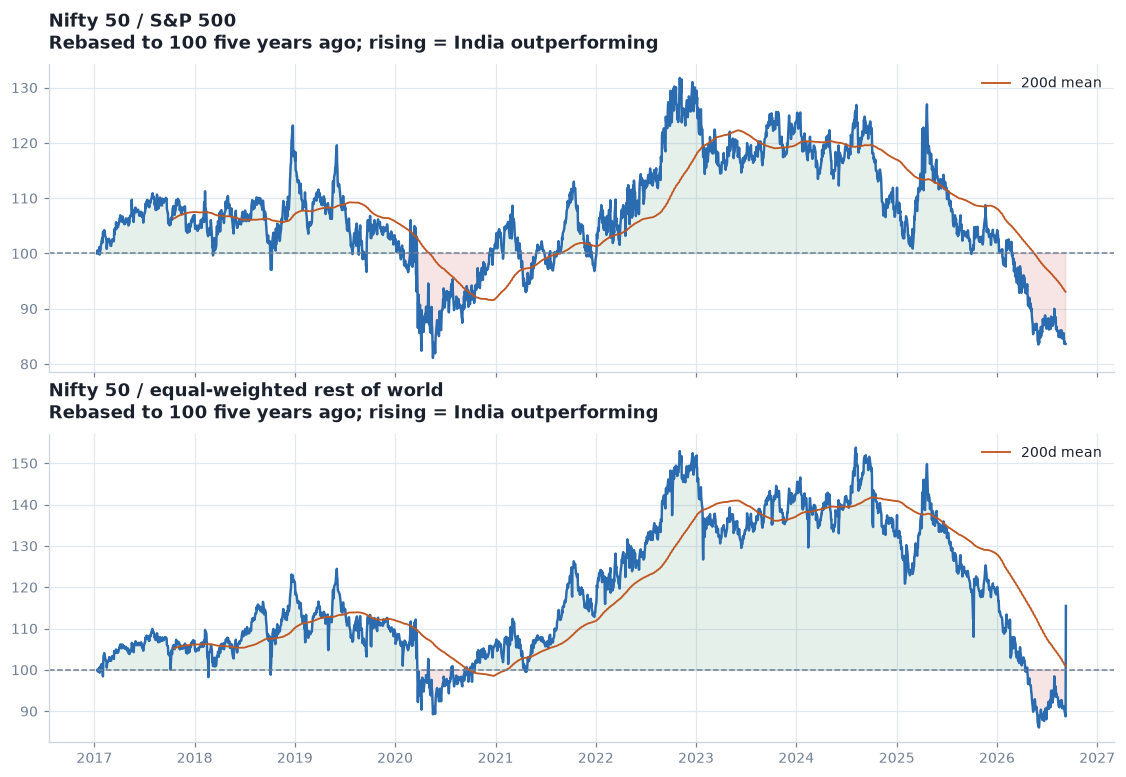

In [11]:
world_eq = px.drop(columns=[c for c in ("Nifty 50", "Sensex") if c in px.columns])
world_basket = align.rebase(world_eq, 100).mean(axis=1)

nifty = px["Nifty 50"]
ratio_us = (nifty / px[names.get("^GSPC", "S&P 500")]).dropna()
ratio_world = (align.rebase(nifty.to_frame("Nifty 50"), 100)["Nifty 50"]
               / world_basket).dropna()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12.5, 8), sharex=True)
for ax, series, label in [(a1, ratio_us, "Nifty 50 / S&P 500"),
                          (a2, ratio_world, "Nifty 50 / equal-weighted rest of world")]:
    s = series.tail(2520)
    s = s / s.iloc[0] * 100
    ax.plot(s.index, s.values, color=viz.PALETTE[0], lw=1.6)
    ax.plot(s.index, s.rolling(200).mean(), color=viz.PALETTE[1], lw=1.2, label="200d mean")
    ax.axhline(100, color=viz.MUTED, ls="--", lw=1)
    ax.fill_between(s.index, 100, s.values, where=(s.values >= 100),
                    color=viz.POS, alpha=0.12, interpolate=True)
    ax.fill_between(s.index, 100, s.values, where=(s.values < 100),
                    color=viz.NEG, alpha=0.12, interpolate=True)
    viz.title(ax, label, "Rebased to 100 five years ago; rising = India outperforming")
    ax.legend()
viz.save(fig, "04_india_vs_world"); plt.show()

In [12]:
def rs_read(series, label):
    s = series.dropna()
    now = float(s.iloc[-1])
    ma = float(s.rolling(200).mean().iloc[-1]) if len(s) > 200 else np.nan
    chg_3m = ind.trailing_return(s, 91)
    chg_12m = ind.trailing_return(s, 365)
    trend = ("outperforming" if np.isfinite(ma) and now > ma else "underperforming")
    return {"pair": label, "3m change %": chg_3m, "12m change %": chg_12m,
            "vs 200d mean": trend}

rs_summary = pd.DataFrame([rs_read(ratio_us, "Nifty / S&P 500"),
                           rs_read(ratio_world, "Nifty / rest of world")])
display(rs_summary.round(2))

india_1y = float(perf.loc["Nifty 50", "1Y_%"])
world_1y = float(perf.drop(index=[c for c in ("Nifty 50", "Sensex") if c in perf.index])["1Y_%"].mean())
excess_1y = india_1y - world_1y

n_beaten = int((perf["1Y_%"] < india_1y).sum())
n_total = int(perf["1Y_%"].notna().sum()) - 1

if excess_1y > 5:
    india_signal = "India leading the world"
elif excess_1y < -5:
    india_signal = "India lagging the world"
else:
    india_signal = "India in line with the world"

print(f"Nifty 50 1-year return : {india_1y:+.2f}%")
print(f"World average (ex-India): {world_1y:+.2f}%")
print(f"Excess                  : {excess_1y:+.2f} pp")
print(f"India outperformed {n_beaten} of {n_total} other markets over 12 months.")
print(f"\nGLOBAL EQUITY SIGNAL: {india_signal}")

,pair,3m change %,12m change %,vs 200d mean
0,Nifty / S&P 500,-2.11,-19.24,underperforming
1,Nifty / rest of world,27.77,-6.63,outperforming


Nifty 50 1-year return : -5.60%
World average (ex-India): +33.52%
Excess                  : -39.12 pp
India outperformed 1 of 13 other markets over 12 months.

GLOBAL EQUITY SIGNAL: India lagging the world


In [13]:
payload = {
    "signal": india_signal,
    "score": round(excess_1y, 2),
    "as_of": str(px.index.max().date()),
    "india_1y_%": round(india_1y, 2),
    "world_ex_india_1y_%": round(world_1y, 2),
    "excess_1y_pp": round(excess_1y, 2),
    "markets_beaten": f"{n_beaten}/{n_total}",
    "returns_1y_%": {c: round(float(v), 2) for c, v in perf["1Y_%"].dropna().items()},
    "drawdown_%": {c: round(float(v), 2) for c, v in dd_now.items()},
    "avg_pairwise_corr": round(float(corr.where(~np.eye(len(corr), dtype=bool)).stack().mean()), 3),
    "india_corr_with_world": round(float(india_corr.mean()), 3),
    "dispersion_now_%": round(float(roll_disp.dropna().iloc[-1]), 2),
    "rs_rank_top3": list(rs_rank.head(3).index),
    "dropped_tickers": [t for t, _ in eq_failed],
}
dashboard.append("04_global_equity", payload)
display(dashboard.summary())

,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-08 15:30:00,2026-09-08 11:48:30
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",81.12,2026-09-08,2026-09-08 11:54:03
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 04:42:58
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 04:49:04
8,09_positioning,"12 names scored, 6 short candidates checked fo...",54.69,2026-09-09,2026-09-09 05:12:38
9,10_portfolio,"6L / 5S, gross 1.01x, net -0.13x",7.25,2026-09-09,2026-09-09 05:01:54


## What this hands to notebook 05

We now know how India is doing *as a block* against the world. Notebook 05 opens the
block up: all NSE indices by sector, official PE/PB/DY valuations, market breadth, the
India VIX regime, FII/DII flows and the market-cap curve from large through micro.

The question changes from "should I be in India?" to **"where in India?"**